### **Lab #6 Linear Regression**

**Task 1: load the ecommerce customers dataset into a dataframe.**

Load the dataset into a DataFrame
Explore the data (head, info, describe)
Perform basic data cleaning if needed
Apply feature engineering (if applicable)
Prepare the data for modeling
Train a model (use the same model used in the lab)
Evaluate the model performance

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [8]:
ecustomers = pd.read_csv('Ecommerce Customers.csv')

**Task 2: Explore the data** 

In [9]:
ecustomers.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [10]:
ecustomers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


In [11]:
ecustomers.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


In [12]:
ecustomers.columns

Index(['Email', 'Address', 'Avatar', 'Avg. Session Length', 'Time on App',
       'Time on Website', 'Length of Membership', 'Yearly Amount Spent'],
      dtype='object')

**Task 3: perform basic data cleaning**

In [18]:
ecustomers.isnull().sum()

Email                   0
Address                 0
Avatar                  0
Avg. Session Length     0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64

In [20]:
ecustomers = ecustomers.fillna(ecustomers.mean(numeric_only=True))

**Task 4: apply feature engineering**

In [21]:
ecomm_model = ecustomers.drop(['Email', 'Address', 'Avatar'], axis=1)
ecomm_model.head()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,34.497268,12.655651,39.577668,4.082621,587.951054
1,31.926272,11.109461,37.268959,2.664034,392.204933
2,33.000915,11.330278,37.110597,4.104543,487.547505
3,34.305557,13.717514,36.721283,3.120179,581.852344
4,33.330673,12.795189,37.536653,4.446308,599.406092


**Task 5: prepare the data for modeling**

In [23]:
from sklearn.model_selection import train_test_split

# Define features and target
X = ecomm_model.drop('Yearly Amount Spent', axis=1)
y = ecomm_model['Yearly Amount Spent']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=101
)

**Task 6: train a model**

In [24]:
from sklearn.linear_model import LinearRegression

lm = LinearRegression()
lm.fit(X_train, y_train)

LinearRegression()

In [25]:
predictions = lm.predict(X_test)

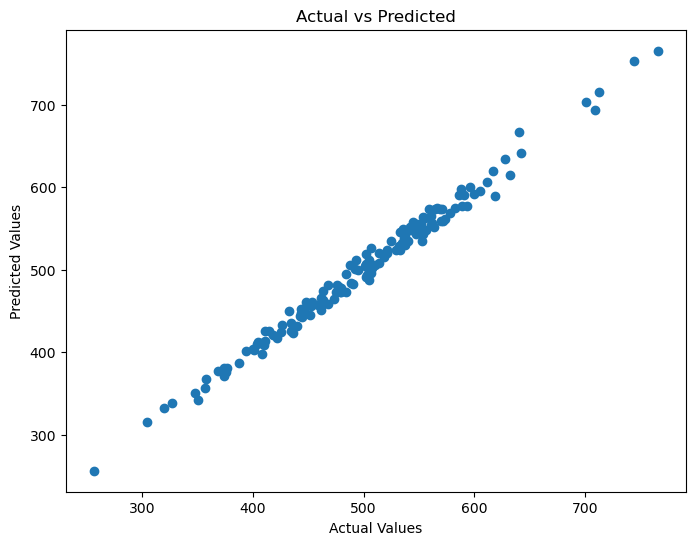

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, predictions)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted')
plt.show()

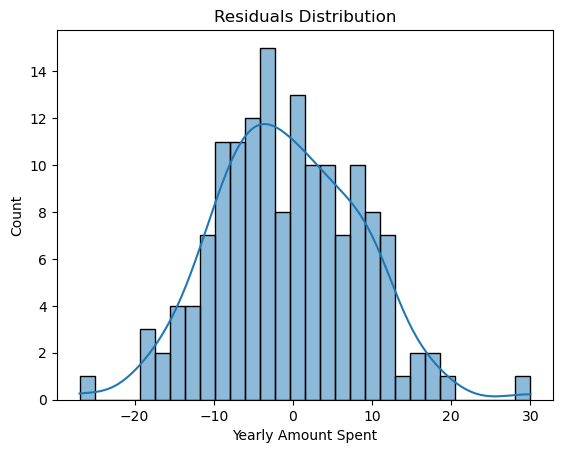

In [27]:
import seaborn as sns

sns.histplot(y_test - predictions, bins=30, kde=True)
plt.title('Residuals Distribution')
plt.show()

In [29]:
from sklearn import metrics

print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))

MAE: 7.228148653430845
MSE: 79.81305165097454
RMSE: 8.933815066978639


In [30]:
coeff_df = pd.DataFrame(lm.coef_, X.columns, columns=['Coefficient'])
coeff_df

,Coefficient
Avg. Session Length,25.981550
Time on App,38.590159
Time on Website,0.190405
Length of Membership,61.279097


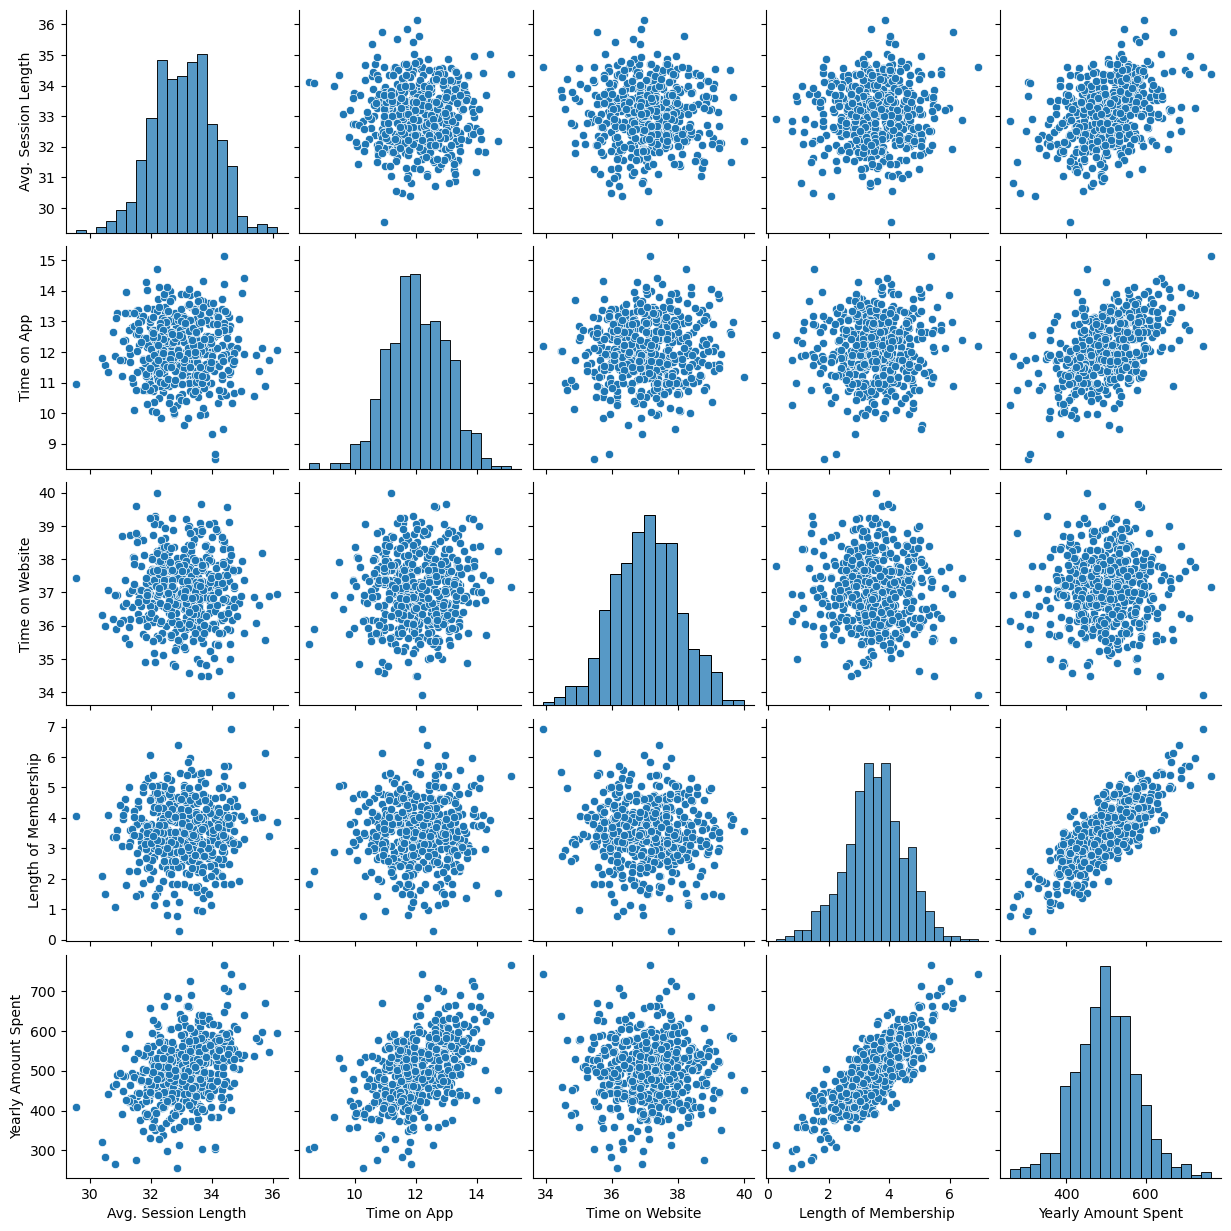

In [13]:
sns.pairplot(ecustomers)
plt.show()

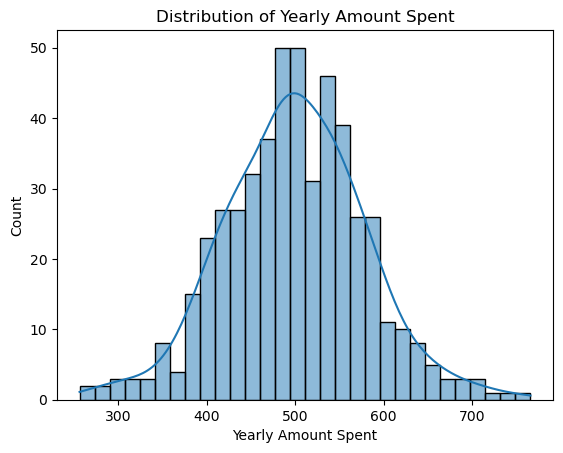

In [14]:
sns.histplot(ecustomers['Yearly Amount Spent'], bins=30, kde=True)
plt.title('Distribution of Yearly Amount Spent')
plt.show()

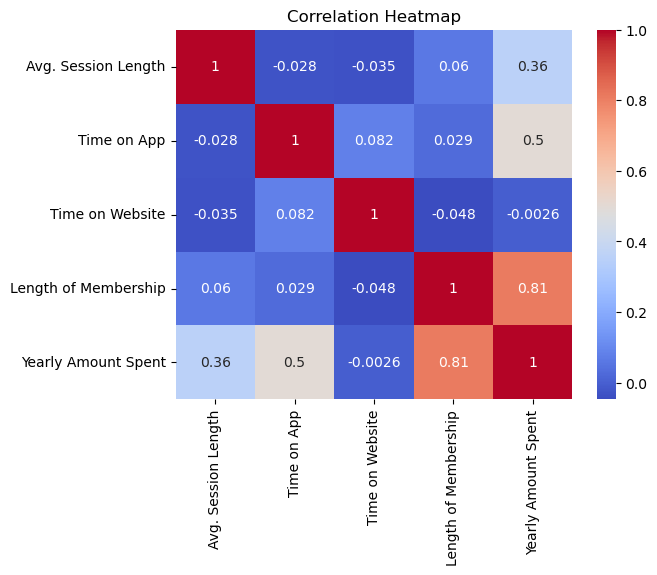

In [15]:
sns.heatmap(ecustomers.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

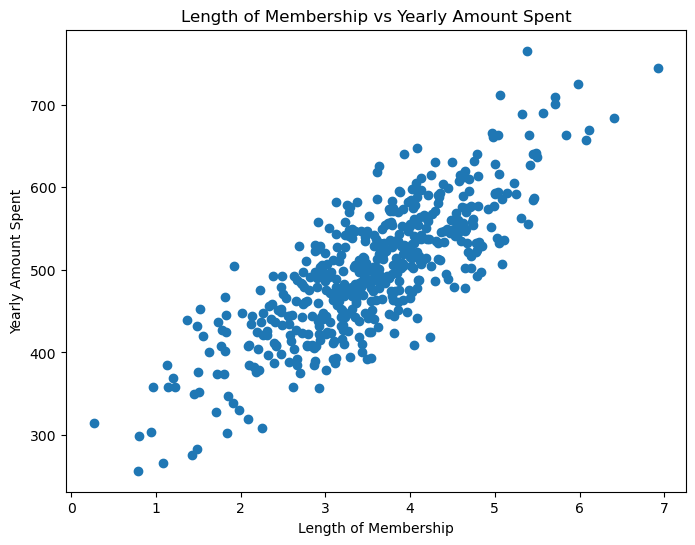

In [16]:
plt.figure(figsize=(8,6))
plt.scatter(ecustomers['Length of Membership'], ecustomers['Yearly Amount Spent'])
plt.xlabel('Length of Membership')
plt.ylabel('Yearly Amount Spent')
plt.title('Length of Membership vs Yearly Amount Spent')
plt.show()

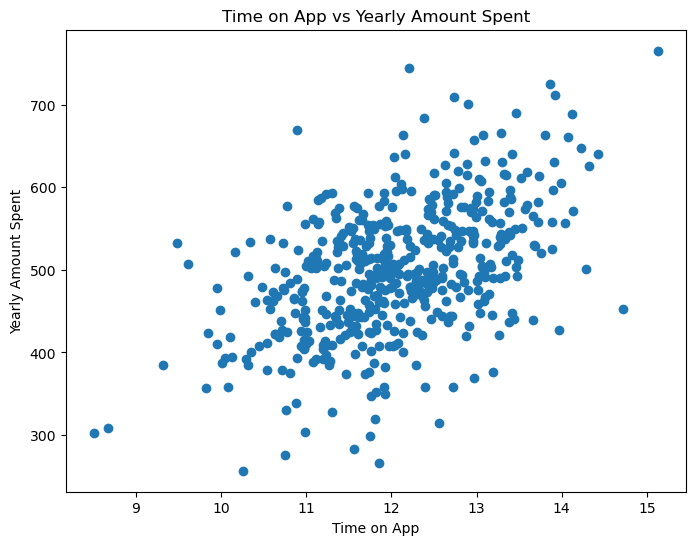

In [17]:
plt.figure(figsize=(8,6))
plt.scatter(ecustomers['Time on App'], ecustomers['Yearly Amount Spent'])
plt.xlabel('Time on App')
plt.ylabel('Yearly Amount Spent')
plt.title('Time on App vs Yearly Amount Spent')
plt.show()